# <center>        **Introduction to Data Science (S2-22_DSECLZG532)-ASSIGNMENT**</center>

## Group No: 053

## Group Member Names:
1. Mohammed Mudassirullah Sheriff
2. Suraj Kumar R C
3. Bhavvya R Sureka
4. Shaurya Mehta

# 1. Business Understanding

Students are expected to identify an analytical problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?
   3. What are the different sources of data?
   4. What kind of analytics task are you performing?

Score: 1 Mark in total (0.25 mark each)

# 2. Data Acquisition

For the problem identified , find an appropriate data set (Your data set must
be unique with minimum **20 features and 10k rows**) from any public data source.

---



## 2.1 Download the data directly



In [18]:
##---------Type the code below this line-----------------

# Install Kaggle to download dataset from kaggle.com
! pip install kaggle

import os
os.environ['KAGGLE_USERNAME'] = 'mudassirsheriff'
os.environ['KAGGLE_KEY'] = 'f7892b671c9df4a3f144bce6aa5c0675'

# Authentication and dataset download from kaggle using Kaggle API
import kaggle as kg

kg.api.authenticate()

kg.api.dataset_download_files(dataset="abdallahwagih/telco-customer-churn", path="./dataset", unzip=True)

from huggingface_hub import hf_hub_download

REPO_ID = "aai510-group1/telco-customer-churn"
FILE_NAME = "train.csv"
hf_hub_download(repo_id=REPO_ID, filename=FILE_NAME, repo_type="dataset", local_dir="./dataset")

# Set the dataset path for further processing
kaggle_dataset_path = os.path.join(os.path.abspath(""),"dataset\Telco_customer_churn.xlsx")
hf_dataset_path = os.path.join(os.path.abspath(""),"dataset\\train.csv")

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/telco-customer-churn


## 2.2 Code for converting the above downloaded data into a dataframe

In [19]:
##---------Type the code below this line------------------##

! pip install pandas 
! pip install openpyxl

import pandas as pd

kaggle_df = pd.read_excel(kaggle_dataset_path)

huggingface_df = pd.read_csv(hf_dataset_path)
huggingface_renaming = {
    "Customer Status": "Churn Label",
    "Churn": "Churn Value",
    "Total Charges": "Total Charges",
    "Zip Code": "Zip Code",
    "City": "City",
    "Contract": "Contract",
    "Country": "Country",
    "CLTV": "CLTV",
    "Customer ID": "CustomerID", 
    "Tenure in Months": "Tenure Months", 
    "Device Protection Plan": "Device Protection", 
    "Monthly Charge": "Monthly Charges",
    "Premium Tech Support": "Tech Support",
    "Internet Service": "Internet Service Value",
    "Internet Type": "Internet Service"
}

huggingface_df.rename(columns=huggingface_renaming, inplace=True)

# Identifying common columns for merging
common_columns = list(set(kaggle_df.columns) & set(huggingface_df.columns))


# Check data types of common columns in both datasets
kaggle_dtypes = kaggle_df[common_columns].dtypes
huggingface_dtypes = huggingface_df[common_columns].dtypes

# Compare data types
dtype_comparison = pd.DataFrame({"Kaggle": kaggle_dtypes, "HuggingFace": huggingface_dtypes})
dtype_comparison[dtype_comparison["Kaggle"] != dtype_comparison["HuggingFace"]]

# Convert Hugging Face dataset columns to match Kaggle dataset types
for col in dtype_comparison.index:
    if kaggle_dtypes[col] == "object":
        huggingface_df[col] = huggingface_df[col].astype(str)
    else:
        huggingface_df[col] = pd.to_numeric(huggingface_df[col], errors='coerce')


df = pd.merge(kaggle_df, huggingface_df, on=common_columns, how="outer")



## 2.3 Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [20]:
##---------Type the code below this line------------------##

# Displaying the first 5 records
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Quarter,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
0,2967-MXRAV,1.0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8992-CEUEN,1.0,United States,California,Arnold,95223,"38.32153, -120.236358",38.321530,-120.236358,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9318-NKNFC,1.0,United States,California,Twain,95984,"40.022184, -121.062384",40.022184,-121.062384,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9975-SKRNR,1.0,United States,California,Sierraville,96126,"39.559709, -120.345639",39.559709,-120.345639,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1423-BMPBQ,1.0,United States,California,Anaheim,92808,"33.850452, -117.726668",33.850452,-117.726668,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:

# Displaying the last 5 records
df.tail()



,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Quarter,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
11263,8249-THVEC,NaN,United States,California,Los Angeles,90041,"34.137412, -118.207607",34.137412,-118.207607,Male,...,Q3,1.0,4.0,0.0,0.0,1919.13,0.0,2916.88,0.0,0.0
11264,6051-PTVNS,NaN,United States,California,Bodfish,93205,"35.523991, -118.400432",35.523991,-118.400432,Female,...,Q3,0.0,3.0,0.0,0.0,1523.50,0.0,2521.60,0.0,0.0
11265,5899-MQZZL,NaN,United States,California,San Ysidro,92173,"32.555828, -117.040073",32.555828,-117.040073,Female,...,Q3,0.0,2.0,1.0,0.0,78.39,0.0,1077.84,1.0,1.0
11266,4536-PLEQY,NaN,United States,California,Los Angeles,90058,"34.001617, -118.222274",34.001617,-118.222274,Male,...,Q3,1.0,3.0,1.0,0.0,535.20,0.0,1535.00,0.0,1.0
11267,9093-FPDLG,NaN,United States,California,Hilmar,95324,"37.394536, -120.890747",37.394536,-120.890747,Female,...,Q3,0.0,3.0,1.0,0.0,104.72,0.0,1104.62,0.0,1.0


## 2.4 Display the column headings, statistical information, description and statistical summary of the data.

In [22]:
##---------Type the code below this line------------------##
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Age', 'Avg Monthly GB Download',
       'Avg Monthly Long Distance Charges', 'Churn Category',
       'Internet Service Value', 'Married', 'Number of Dependents',
       'Number of Referrals', 'Offer', 'Population', 'Quarter',
       'Referred a Friend', 'Satisfaction Score', 'Streaming Music',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data'],
      dtype='object

In [23]:
#Statistical information like data types, counts etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11268 entries, 0 to 11267
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CustomerID                         11268 non-null  object 
 1   Count                              7043 non-null   float64
 2   Country                            11268 non-null  object 
 3   State                              11268 non-null  object 
 4   City                               11268 non-null  object 
 5   Zip Code                           11268 non-null  int64  
 6   Lat Long                           11268 non-null  object 
 7   Latitude                           11268 non-null  float64
 8   Longitude                          11268 non-null  float64
 9   Gender                             11268 non-null  object 
 10  Senior Citizen                     11268 non-null  object 
 11  Partner                            11268 non-null  obj

In [24]:
#Description and Statistical summary
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV,Age,...,Population,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
count,7043.0,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,4225.000000,...,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000
mean,1.0,93510.689031,36.254257,-119.787371,32.487664,64.815974,0.265353,58.542599,4403.841143,46.451124,...,22008.756686,0.459882,3.242367,0.349586,6.965680,754.719141,1.953846,3065.809082,0.200000,0.677870
std,0.0,1864.847656,2.461655,2.156416,24.581949,30.027400,0.441541,21.403047,1178.358249,16.731518,...,20965.262169,0.498447,1.200716,0.476896,25.250169,854.909725,7.814374,2884.817379,0.400047,0.467348
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000,19.000000,...,11.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000
25%,1.0,92102.000000,34.018354,-121.805845,9.000000,35.787500,0.000000,40.000000,3475.000000,32.000000,...,2346.000000,0.000000,3.000000,0.000000,0.000000,67.680000,0.000000,592.750000,0.000000,0.000000
50%,1.0,93541.000000,36.303793,-119.710008,29.000000,70.300000,0.000000,61.000000,4529.000000,46.000000,...,17554.000000,0.000000,3.000000,0.000000,0.000000,396.640000,0.000000,2151.470000,0.000000,1.000000
75%,1.0,95346.000000,38.208336,-118.020188,56.000000,89.850000,1.000000,75.000000,5381.000000,60.000000,...,35737.000000,1.000000,4.000000,1.000000,0.000000,1200.000000,0.000000,4845.750000,0.000000,1.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000,80.000000,...,105285.000000,1.000000,5.000000,1.000000,150.000000,3564.000000,49.790000,11979.340000,1.000000,1.000000


In [25]:
# Check for columns with null values
df.isna().sum()

CustomerID                               0
Count                                 4225
Country                                  0
State                                    0
City                                     0
Zip Code                                 0
Lat Long                                 0
Latitude                                 0
Longitude                                0
Gender                                   0
Senior Citizen                           0
Partner                                  0
Dependents                               0
Tenure Months                            0
Phone Service                            0
Multiple Lines                           0
Internet Service                         0
Online Security                          0
Online Backup                            0
Device Protection                        0
Tech Support                             0
Streaming TV                             0
Streaming Movies                         0
Contract   

## 2.5 Write your observations from the above.
1. Size of the dataset
2. What type of data attributes are there?
3. Is there any null data that has to be cleaned?

Score: 2 Marks in total (0.25 marks for 2.1, 0.25 marks for 2.2, 0.5 marks for 2.3, 0.25 marks for 2.4, 0.75 marks for 2.5)

# 3. Data Preparation

## 3.1 Check for

* duplicate data
* missing data
* data inconsistencies


In [26]:
##---------Type the code below this line------------------##

# Checking for duplicates
duplicates = df.duplicated().sum()

if duplicates > 0:
    print(f"Duplicates rows available: {duplicates}")
else:
    print("No Duplicates in the datatset")

# Checking for missing Data
missing_values = df.isnull().sum() 
missing_percentage = (missing_values / len(df)) * 100
# Filter columns with missing data
missing_summary = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percentage}) 
missing_summary = missing_summary[missing_summary["Missing Values"] > 0].sort_values(by="Percentage", ascending=False)

print(missing_summary)

No Duplicates in the datatset
                                   Missing Values  Percentage
Churn Category                              10147   90.051473
Offer                                        9367   83.129215
Avg Monthly GB Download                      7043   62.504437
Avg Monthly Long Distance Charges            7043   62.504437
Internet Service Value                       7043   62.504437
Age                                          7043   62.504437
Satisfaction Score                           7043   62.504437
Streaming Music                              7043   62.504437
Number of Dependents                         7043   62.504437
Married                                      7043   62.504437
Number of Referrals                          7043   62.504437
Population                                   7043   62.504437
Quarter                                      7043   62.504437
Referred a Friend                            7043   62.504437
Total Refunds                           

## 3.2 Apply techiniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies


In [27]:
##---------Type the code below this line------------------##

# Handling missing data
    # Define threshold for dropping columns (e.g., >60% missing values)
threshold = 60
cols_to_drop = missing_summary[missing_summary["Percentage"] > threshold].index

# Drop these columns
df_cleaned = df.drop(columns=cols_to_drop)

# Fill missing numerical columns with median values
num_cols = df_cleaned.select_dtypes(include=["number"]).columns
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())

# Fill missing categorical columns with mode (most frequent value)
cat_cols = df_cleaned.select_dtypes(include=["object"]).columns

# Standardizing categorical values (e.g., Yes/No, trimming whitespace)
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()


cat_value_counts = {col: df_cleaned[col].unique()[:10] for col in cat_cols}  # Show first 10 unique values per column
df_cleaned[cat_cols] = df_cleaned[cat_cols].fillna(df_cleaned[cat_cols].mode().iloc[0])

# Verify remaining missing values
print(f"After Data cleaning, the number of missing values")
df_cleaned.isnull().sum()

# Handling Data inconsistencies
# Standardizing binary categorical columns (yes/no instead of 1/0)
binary_cols = [
    "Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"
]

for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].replace({"1": "yes", "0": "no"})

# Standardizing service-related columns to remove "no internet service" or "no phone service"
service_cols = [
    "Multiple Lines", "Online Security", "Online Backup", "Device Protection", 
    "Tech Support", "Streaming TV", "Streaming Movies"
]

for col in service_cols:
    df_cleaned[col] = df_cleaned[col].replace(
        {"no internet service": "no", "no phone service": "no"}
    )

# Cleaning up Churn Label
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"nan": None}).fillna("no")
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"churned": "yes"})
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"stayed": "no"})
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"joined": "no"})

# Converting Total Charges to numeric:
df_cleaned["Total Charges"] = pd.to_numeric(df_cleaned["Total Charges"], errors="coerce")
df_cleaned.fillna({"Total Charges":df_cleaned["Total Charges"].median()}, inplace=True)

# Verify the cleaned data
print("Data after cleaning categorical columns")
df_cleaned[binary_cols + service_cols + ["Churn Label", "Churn Value", "Total Charges"]].head()




After Data cleaning, the number of missing values
Data after cleaning categorical columns


,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Churn Label,Churn Value,Total Charges
0,no,yes,no,yes,no,no,no,no,no,no,no,no,no,0,18.80
1,no,no,no,yes,no,no,no,no,no,no,no,no,no,0,18.85
2,no,no,no,yes,yes,no,no,no,no,no,no,no,yes,1,18.85
3,no,no,no,yes,no,no,no,no,no,no,no,no,no,0,18.90
4,no,yes,yes,yes,yes,no,no,no,no,no,no,no,no,0,19.00


## 3.3 Encode categorical data

In [28]:
##---------Type the code below this line------------------##


## 3.4 Report

Mention and justify the method adopted
* to remove duplicate data, if present
* to impute or remove missing data, if present
* to remove data inconsistencies, if present

OR for textdata
* How many tokens after step 3?
* how may tokens after stop words filtering?

If the any of the above are not present, then also add in the report below.

Score: 2 Marks (based on the dataset you have, the data prepreation you had to do and report typed, marks will be distributed between 3.1, 3.2, 3.3 and 3.4)

In [29]:
##---------Type the code below this line------------------##
print('''
1. Handling Duplicate Data
    Method Used:
        Identified duplicate rows using merged_df.duplicated().sum().
        If duplicate rows were found, they would be removed using df_cleaned.drop_duplicates(inplace=True).
    Justification:
        Duplicate rows can cause redundancy and skew results. Removing them ensures data integrity.
 
2. Handling Missing Data
    Method Used: 
        Identified missing values and calculated their percentage.
        Dropped columns where missing values exceeded 60%.
        Imputed missing numerical values with the median.
        Imputed missing categorical values with the mode.
    Justification:
        Dropping columns with excessive missing values prevents biased data.
        The median is robust against outliers in numerical data.
        The mode maintains categorical consistency.
 
3. Handling Data Inconsistencies
    Method Used:
        Standardized categorical values (converted to lowercase, removed whitespaces).
        Replaced inconsistent categorical values (e.g., "no internet service" → "no").
        Converted binary categorical columns ("1" → "yes", "0" → "no").
        Converted "Total Charges" to numeric format (pd.to_numeric).
    Justification:
        Standardizing categorical values ensures uniformity.
        Replacing service-related inconsistencies improves data usability.
        Numeric conversion allows for correct calculations.
''')


1. Handling Duplicate Data
    Method Used:
        Identified duplicate rows using merged_df.duplicated().sum().
        If duplicate rows were found, they would be removed using df_cleaned.drop_duplicates(inplace=True).
    Justification:
        Duplicate rows can cause redundancy and skew results. Removing them ensures data integrity.
 
2. Handling Missing Data
    Method Used: 
        Identified missing values and calculated their percentage.
        Dropped columns where missing values exceeded 60%.
        Imputed missing numerical values with the median.
        Imputed missing categorical values with the mode.
    Justification:
        Dropping columns with excessive missing values prevents biased data.
        The median is robust against outliers in numerical data.
        The mode maintains categorical consistency.
 
3. Handling Data Inconsistencies
    Method Used:
        Standardized categorical values (converted to lowercase, removed whitespaces).
        Replaced in

## 3.5 Identify the target variables.

* Separate the data from the target such that the dataset is in the form of (X,y) or (Features, Label)

* Discretize / Encode the target variable or perform one-hot encoding on the target or any other as and if required.

* Report the observations

Score: 1 Mark

In [30]:
##---------Type the code below this line------------------##

# Segregating data into features and label
target_column = "Churn Label"

# Encoding the target label
! pip install scikit-learn

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoder = LabelEncoder()
df_cleaned["Churn Label"] = label_encoder.fit_transform(df_cleaned["Churn Label"])

#Encoding Binary category cols
for col in binary_cols:
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype(str)
    df_cleaned[col] = LabelEncoder().fit_transform(df_cleaned[col])

print("After encoding category cols")
print(df_cleaned[binary_cols].head())
print(df_cleaned[categorical_cols].head())

X = df_cleaned.drop(columns=[target_column])  # Features
y = df_cleaned[target_column].astype('str')  # Target Label


# Check class distribution
churn_counts = y.value_counts()
churn_percentage = y.value_counts(normalize=True) * 100

print("\nChurn Distribution:\n", churn_counts)
print("\nChurn Percentage:\n", churn_percentage)

After encoding category cols
   Senior Citizen  Partner  Dependents  Phone Service  Paperless Billing
0               0        1           0              1                  0
1               0        0           0              1                  0
2               0        0           0              1                  1
3               0        0           0              1                  0
4               0        1           1              1                  1
   CustomerID  Country  State  City  Lat Long  Gender  Multiple Lines  \
0        2060        0      0   562       360       1               2   
1        6350        0      0    39      1262       0               2   
2        6560        0      0  1036      1548       1               2   
3        7033        0      0   937      1509       1               2   
4         981        0      0    23       287       0               2   

   Internet Service  Online Security  Online Backup  Device Protection  \
0                 4 

# 4. Data Exploration using various plots



## 4.1 Scatter plot of each quantitative attribute with the target.

Score: 1 Mark

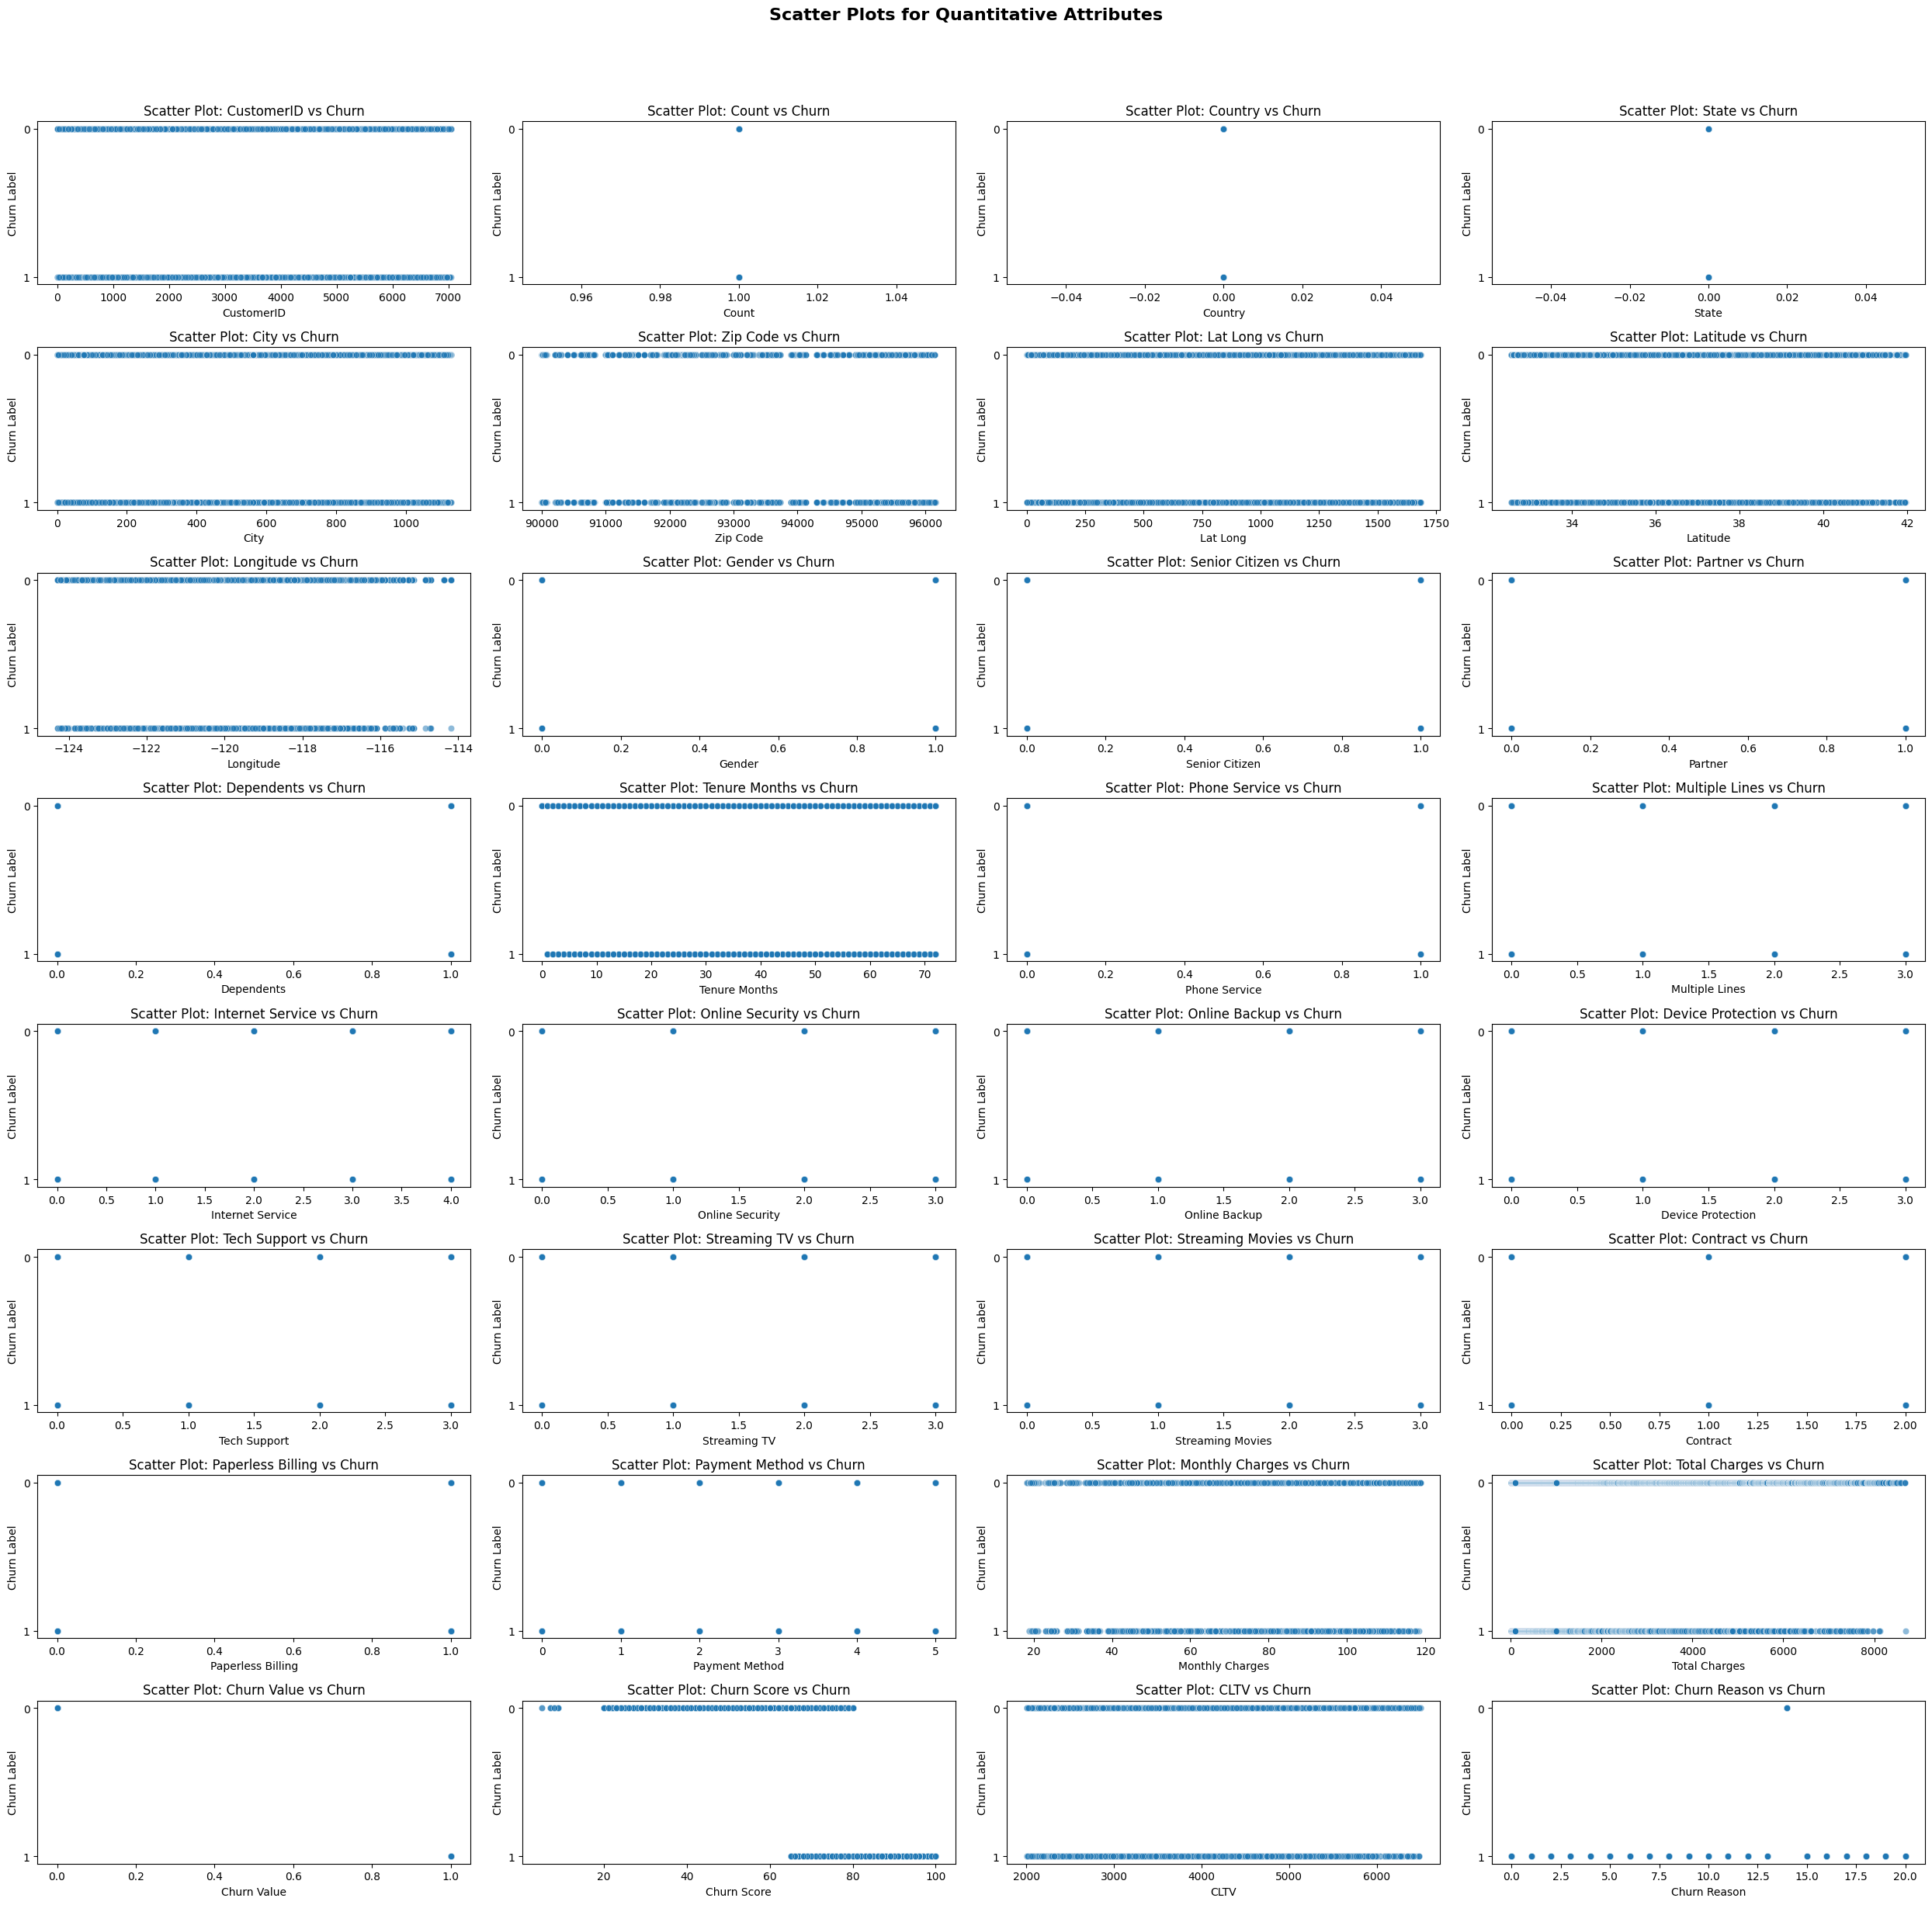

In [31]:
##---------Type the code below this line------------------##
! pip install seaborn
! pip install matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features
quantitative_cols = X.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(25, 25))
plt.suptitle("Scatter Plots for Quantitative Attributes",fontsize=16, fontweight='bold')
for i, feature in enumerate(quantitative_cols, 1):
  #plt.figure(figsize=(15, 4))
  plt.subplot(8, 4, i)  # Adjust rows & columns based on feature count
  sns.scatterplot(x=X[feature], y=y, alpha=0.5)
  plt.xlabel(feature)
  plt.ylabel("Churn Label")
  plt.title(f"Scatter Plot: {feature} vs Churn")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4.2 EDA using visuals
* Use (minimum) 2 plots (pair plot, heat map, correlation plot, regression plot...) to identify the optimal set of attributes that can be used for classification.
* Name them, explain why you think they can be helpful in the task and perform the plot as well. Unless proper justification for the choice of plots given, no credit will be awarded.

Score: 2 Marks

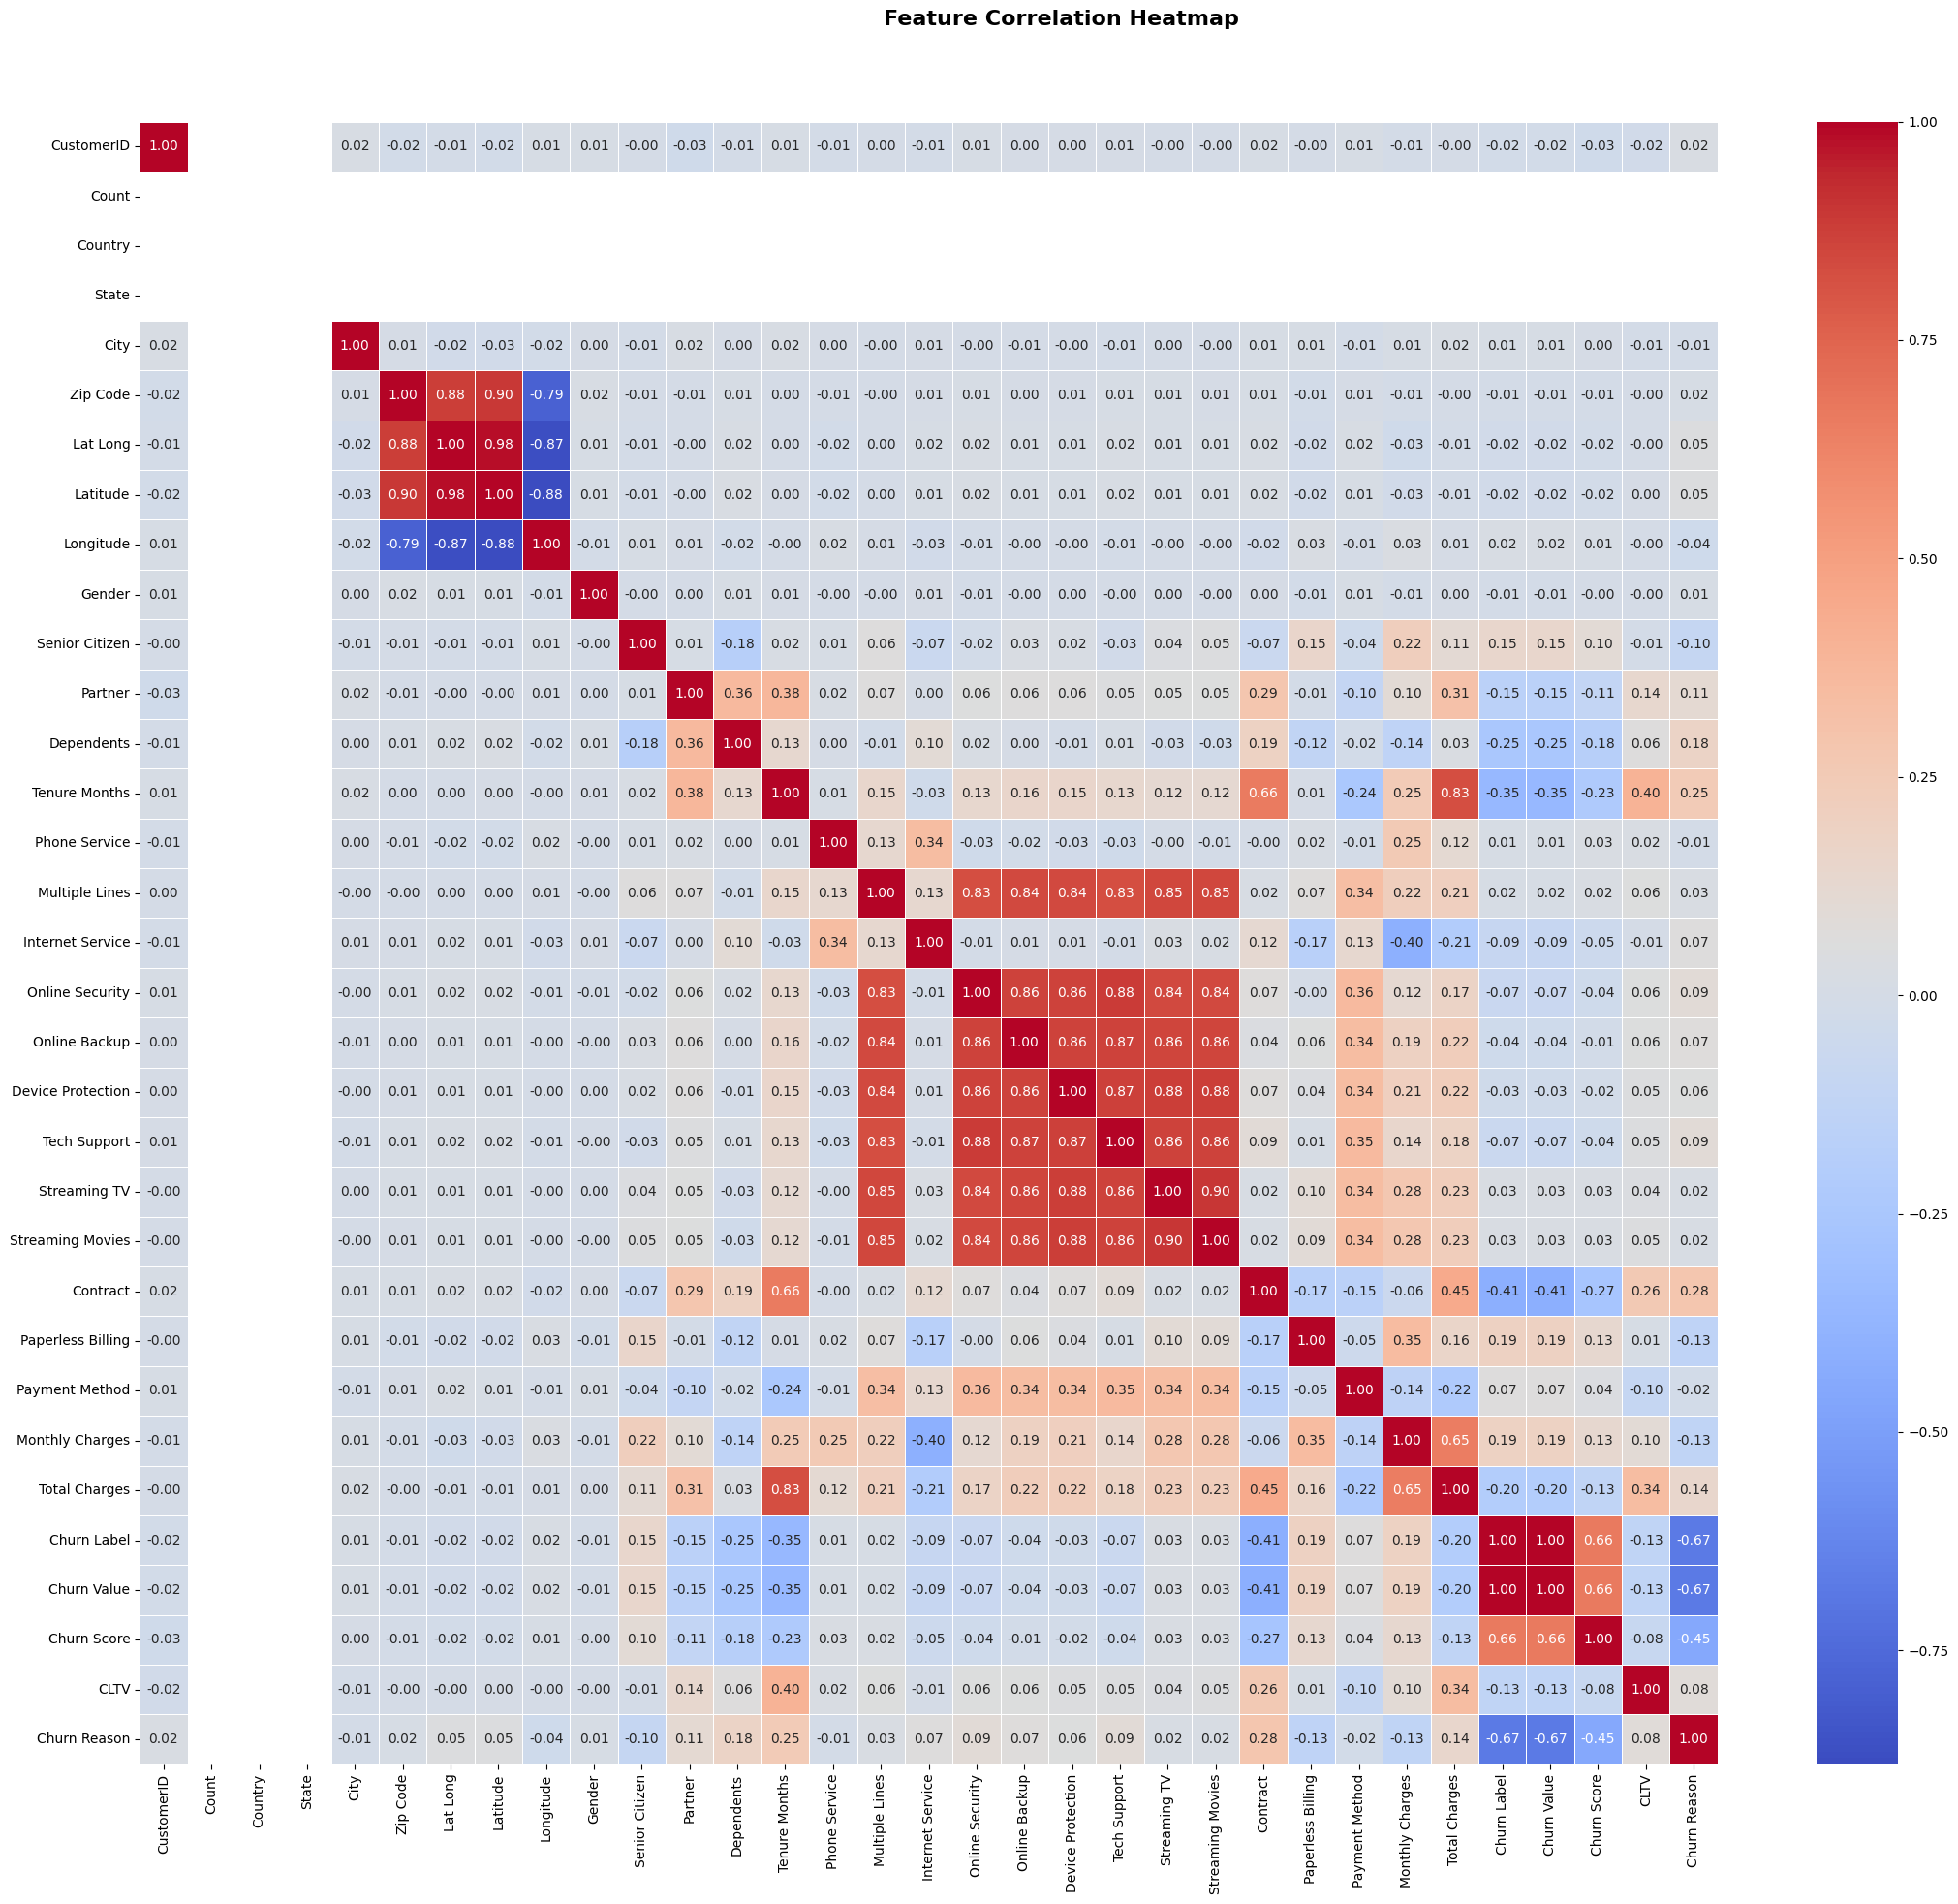

In [ ]:
##---------Type the code below this line------------------##
#-------------------- Correlation Heatmap --------------------
plt.figure(figsize=(22, 20))
sns.heatmap(df_cleaned.corr(method="pearson", numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.suptitle("Feature Correlation Heatmap",fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Pair Plaot -----
sns.pairplot(df_cleaned[quantitative_cols],y_vars=y, hue='Churn Label', palette=["blue", "orange"])
plt.suptitle("Pair Plot",fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Based on the scatter plots, we can drop some features with minimal distribution
df_cleaned.drop(columns=['Count','Country','State', 'Churn Value'], inplace=True)


Justification

1. Correlation Heatmap
 The heatmap provides a visual representation of the correlation between numerical variables, helping to identify strong and weak relationships.
 Strong correlations between features suggest redundancy, while weak correlations indicate independent variables that could add predictive value.

2. Pair Plot
 The pair plot helps identify relationships between numerical features by plotting them against each other. It highlights correlations, clusters, and distributions that may affect churn prediction.
 The diagonal density plots show the distribution of each numerical feature, making it easier to spot skewness and outliers.

 

# 5. Data Wrangling



## 5.1 Univariate Filters

#### Numerical and Categorical Data
* Identify top 5 significant features by evaluating each feature independently with respect to the target/other variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Strenth of Association

(From the above 5 you are required to use only any <b>two</b>)



Score: 3 Marks

In [ ]:
##---------Type the code below this line------------------##
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler


X_numeric = X.select_dtypes(include=["int64", "float64"])

# Mutual Information
mi_scores = mutual_info_classif(X_numeric, y, discrete_features=False)
mi_series = pd.Series(mi_scores, index=X_numeric.columns).sort_values(ascending=False)
print("Top 5 Features by Mutual Information:")
print(mi_series.head(5))

# Chi-Squared Test

# Scale numerical features to (0,1) for chi2 test
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numeric)

chi_scores, p_values = chi2(X_scaled, y)
chi_series = pd.Series(chi_scores, index=X_numeric.columns).sort_values(ascending=False)
print("Top 5 Features by Chi-Squared Test:")
print(chi_series.head(5))



## 5.2 Report observations

Write your observations from the results of each method. Clearly justify your choice of the method.

Score 1 mark

Observations: 
1. Mutual Information:
    This method helps capture non-linear relationships between features and churn. It identifies dependencies that are not necessarily linear, allowing us to discover subtle influences that traditional correlation might miss.
    Features with high mutual information scores contribute significantly to churn prediction, making them essential for model training.

2. Chi-Squared Test:
    The Chi-Squared test evaluates the statistical significance of categorical features in predicting churn. High chi-squared values indicate strong relationships with churn, making them important predictors.")
    This method is particularly useful for understanding which features differentiate churned and non-churned customers effectively."

    Overlap of Features: 
        The overlap of top features from both methods suggests strong predictors of churn. When a feature ranks highly in multiple selection methods, it reinforces its importance for classification."
 

# 6. Implement Machine Learning Techniques

Use any 2 ML tasks
1. Classification  

2. Clustering  

3. Association Analysis

4. Anomaly detection

You may use algorithms included in the course, e.g. Decision Tree, K-means etc. or an algorithm you learnt on your own with a brief explanation.
A clear justification have to be given for why a certain algorithm was chosen to address your problem.

Score: 4 Marks (2 marks each for each algorithm)

## 6.1 ML technique 1 + Justification

Classification Technique:

A Decision Tree Classifier is ideal for predicting whether a customer will churn (yes) or not churn (no) because:

   1.Easy to Interpret – The decision tree provides clear rules for why a customer is likely to churn.  
   2.Handles Both Categorical & Numerical Data – No need for complex preprocessing.  
   3.Feature Importance – It identifies the most important factors influencing churn (e.g., Contract Type, Monthly Charges).  
   4.Non-Linear Relationships – Unlike Logistic Regression, Decision Trees capture complex interactions between features.  
   5.Fast & Efficient – Works well even for large datasets.


In [ ]:
##---------Type the code below this line------------------##
# Justification for using Decision 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Filter the top features alone

#--- Identified top features --
top_features = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Score", "CLTV", "Contract", "Churn Reason"]

X = X[top_features]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Model Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

## 6.2 ML technique 2 + Justification

K-Means Clustering:

K-Means Clustering helps group customers into similar behavioral segments, which is useful when we don’t have predefined labels.

    1.Finds Patterns in Data – It identifies hidden groups of customers based on their behavior.  
    2.Helps with Customer Segmentation – We can create targeted marketing strategies for different clusters.  
    3.Reduces Dimensionality – It simplifies complex data by grouping similar customers.  
    4.Pre-Churn Detection – Clusters with high churn probability can be analyzed further.  

A business can use K-Means to segment customers and identify at-risk clusters that need special retention strategies.

In [ ]:
##---------Type the code below this line------------------##
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Standardize features for K-Means clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K-Means model (assume 2 clusters for churn & non-churn)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataset
X["Cluster"] = clusters

# Count how many customers fall into each cluster
print("Cluster Distribution:\n", X["Cluster"].value_counts())


## 7. Conclusion

Compare the performance of the ML techniques used.

Derive values for preformance study metrics like accuracy, precision, recall, F1 Score, AUC-ROC etc to compare the ML algos and plot them. A proper comparision based on different metrics should be done and not just accuracy alone, only then the comparision becomes authentic. You may use Confusion matrix, classification report, Word cloud etc as per the requirement of your application/problem.

Score 1 Mark

Comparison of ML Techniques

Decision Tree Classifier
 
    Accuracy: 92.63%
    Precision (Class 1 - Churn): 82%
    Recall (Class 1 - Churn): 91%
    F1-Score (Class 1 - Churn): 86%
    Confusion Matrix: Shows the number of correct and incorrect predictions for both churn and non-churn customers.

    Key Insights: The Decision Tree performed well with high accuracy, recall, and F1-score, therefore making it a reliable model for predicting churn. Its ability to handle both categorical and numerical data, interpretability, and feature importance analysis makes it a practical choice for business.
 
K-Means Clustering
 
    Segmented customers into two clusters (potential churners and non-churners).
    Identified hidden patterns in customer behavior, which can help businesses create targeted retention strategies.
    Unlike classification, clustering does not rely on predefined labels but instead finds structure in data.
 
    Key Insights: While K-Means does not provide direct performance metrics like accuracy or F1-score, it helps in customer segmentation and pre-churn detection. Clusters can be further analyzed to identify risk-prone customers and apply targeted interventions.  
 
Final Comparison & Recommendation

    For direct churn prediction, the Decision Tree Classifier is a better choice due to its high accuracy and explainability.

    For customer segmentation and identifying churn-prone groups, K-Means Clustering is valuable as it uncovers hidden patterns and enables targeted marketing strategies.
 

## 8. Solution

What is the solution that is proposed to solve the business problem discussed in Section 1. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

Score 2 Marks

--------------Type the answers below this line--------------

Proposed Solution:

Based on the data analysis and model development, we are proposing the below 2 options which can help tackle the problem
of customer churn.

a) Create segmented retention campaigns.
b) Use the Prediction Model to predict which customers are likely to leave and proactively engage them
by personalized retention strategies (discounts, better plans, improved service). 

Challenges Faced:
1. Identification of dataset with sufficient size, which lead us to make use of 2 datasets of similar attributes
and merge them to provide the required volume.
2. Based on the datset, we have made the critical decision to go with the prediction model as this is more effective
in solving the problem statement than other models.

##NOTE
All Late Submissions will incur a penalty of -2 marks. Do ensure on time submission to avoid penalty.

Good Luck!!!